In [5]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [7]:
df = pd.read_csv("netflix_titles.csv")

In [46]:
df.info()
#1.-Carga y Exploracion del dataset(Capa-DATA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   cast          7982 non-null   object
 4   country       8807 non-null   object
 5   date_added    8807 non-null   object
 6   release_year  8807 non-null   int64 
 7   rating        8803 non-null   object
 8   duration      8804 non-null   object
 9   listed_in     8807 non-null   object
 10  description   8807 non-null   object
dtypes: int64(1), object(10)
memory usage: 757.0+ KB


In [7]:
#Mostrar las primeras filas 5 en este caso
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [17]:
#Mostrar las dimensiones
df.ndim

2

In [11]:
#Mostrar los nombres de las columnas
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [14]:
#Mostrar tipos de datos
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [15]:
#2.- Limpieza de datos

In [16]:
#Identificar valores nulos
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [20]:
#Detectar registros duplicados
df.duplicated().sum()

np.int64(0)

In [24]:
#Aplicar estrategias de limpieza
#Poner todas las columnas en minuscula aunque en este caso las columnas todas ya estan en minuscula
df.columns = df.columns.str.strip().str.lower()

In [30]:
#Identificamos los la cantidad de valores nulos en cada columna
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [32]:
#Hacemos limpieza de la columna director que es la que mas valores nulos tiene
#Eliminamos la columna director
df.drop(columns=["director"], inplace=True)

In [33]:
#Columna director eliminadoa
df.columns

Index(['show_id', 'type', 'title', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [37]:
#Rellenamos date_added con su valor mas repetido
df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])

In [39]:
#Verificamos que deje de tener valores nulos
df.isnull().sum()

show_id           0
type              0
title             0
cast            825
country         831
date_added        0
release_year      0
rating            4
duration          3
listed_in         0
description       0
dtype: int64

In [41]:
#Rellenamos date_added con su valor mas repetido
df["country"] = df["country"].fillna(df["country"].mode()[0])

In [44]:
#Verificamos que deje de tener valores nulos
df.isnull().sum()

show_id           0
type              0
title             0
cast            825
country           0
date_added        0
release_year      0
rating            4
duration          3
listed_in         0
description       0
dtype: int64

In [ ]:
#Se elimino la columna de director debido a que esta tenia una gran cantidad de valores nulos
#Lo cual nos indica que su uso no es tan necesario 

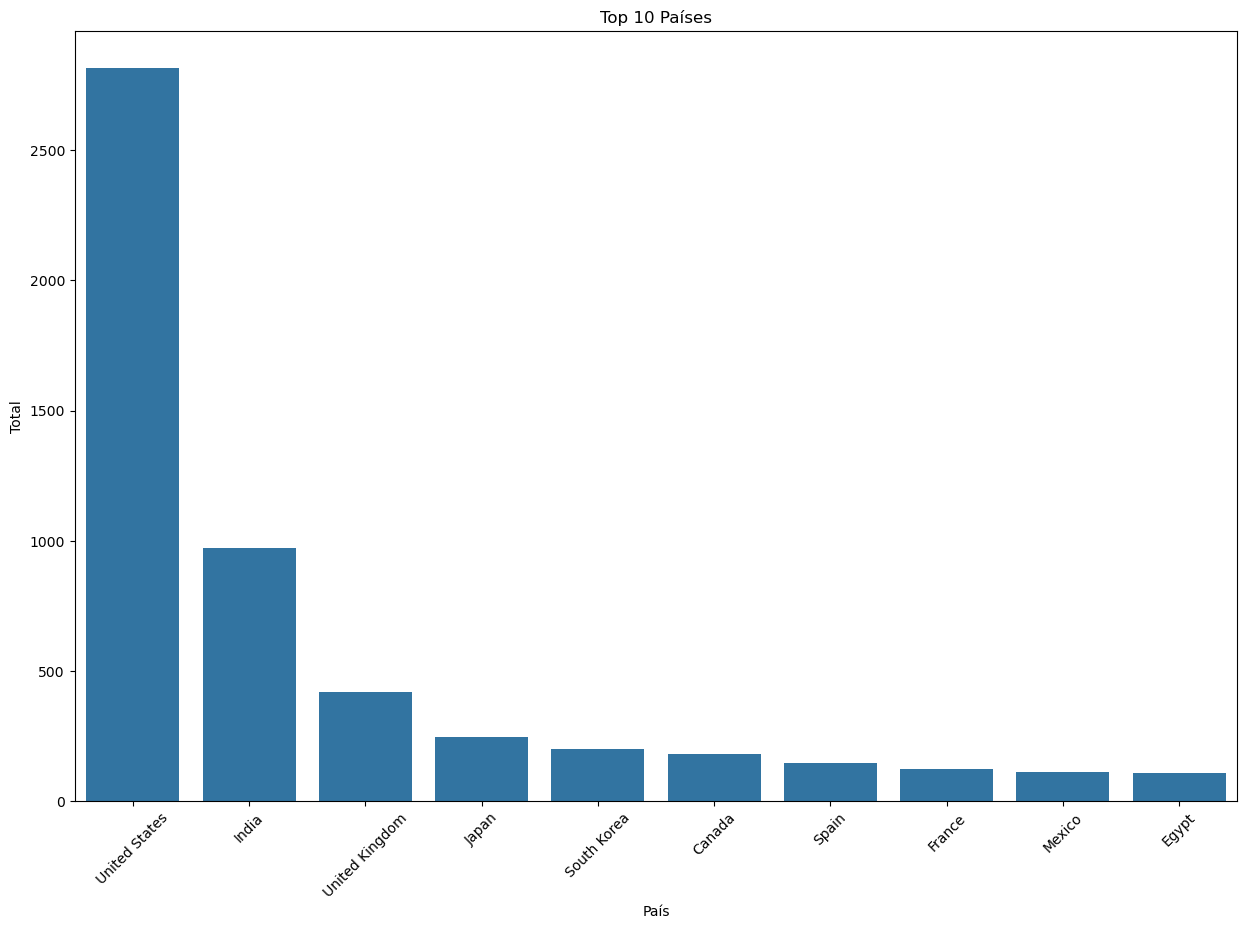

In [11]:
# Grafica 1 Paises
plt.figure(figsize=(15,10))

# Top 10 países
top_paises = df["country"].value_counts().head(10).index

sns.countplot(data=df, x="country", order=top_paises)

plt.title("Top 10 Países")
plt.xlabel("País")
plt.ylabel("Total")

plt.xticks(rotation=45)

plt.show()

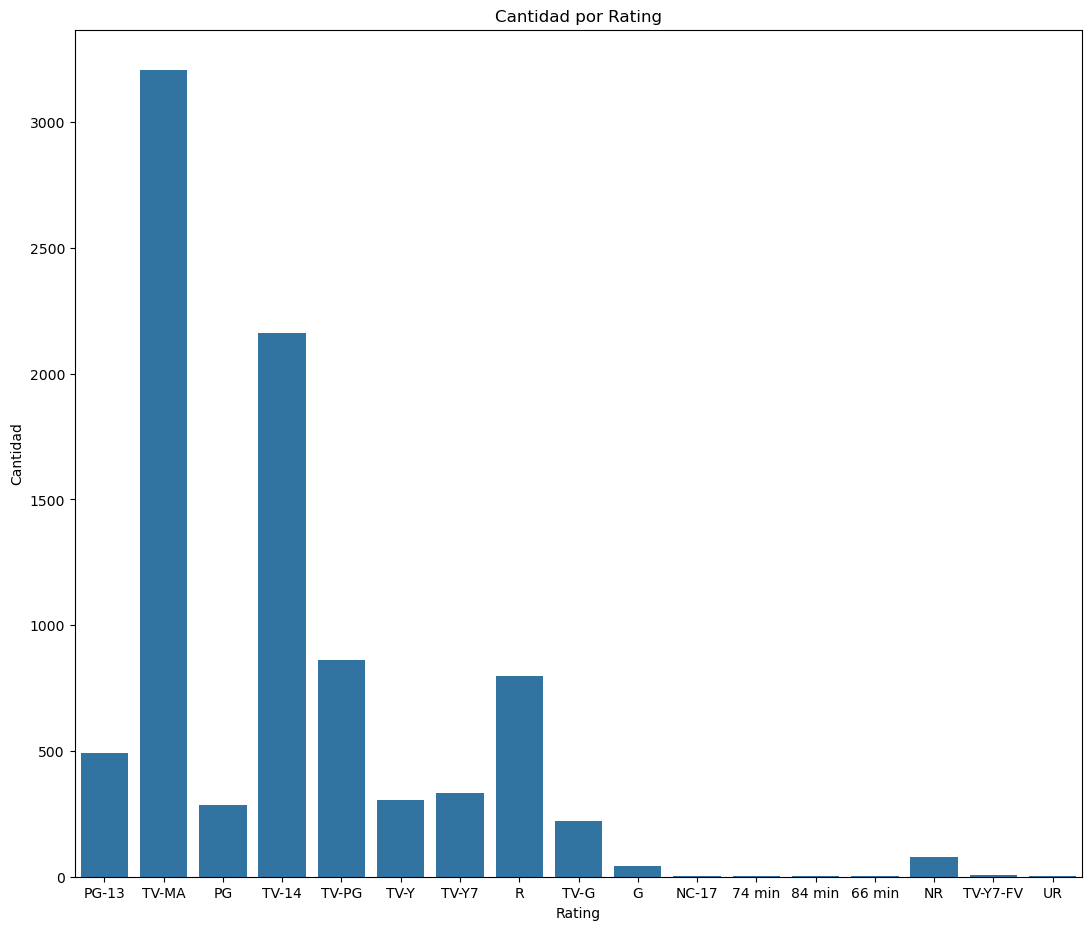

In [77]:
#Grafica 2
plt.figure(figsize=(13,11))
sns.countplot(df, x="rating")
plt.title("Cantidad por Rating")
plt.xlabel("Rating")
plt.ylabel("Cantidad")
plt.show()

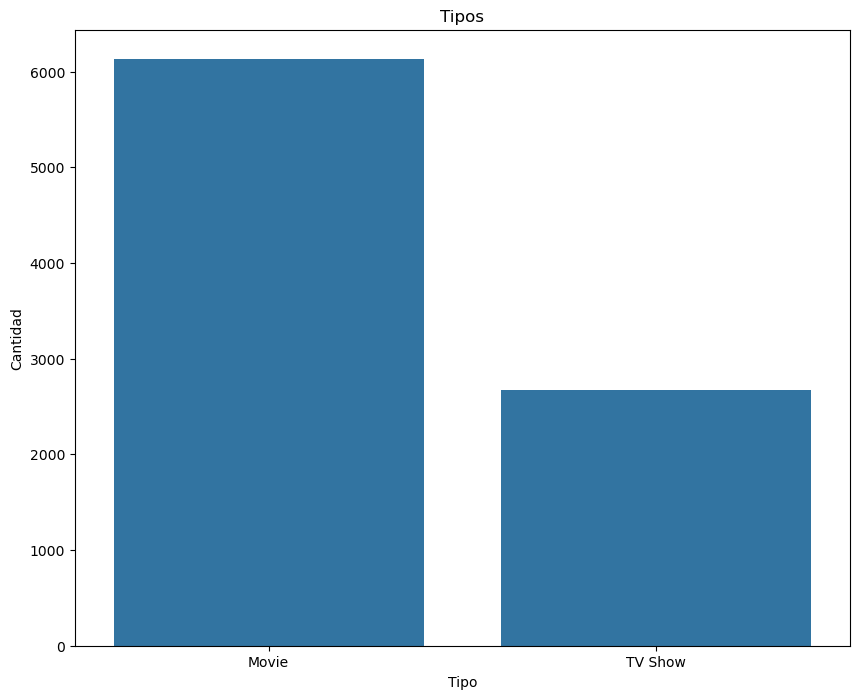

In [10]:
#Grafica 3
plt.figure(figsize=(10,8))
sns.countplot(df, x="type")
plt.title("Tipos")
plt.xlabel("Tipo")
plt.ylabel("Cantidad")
plt.show()

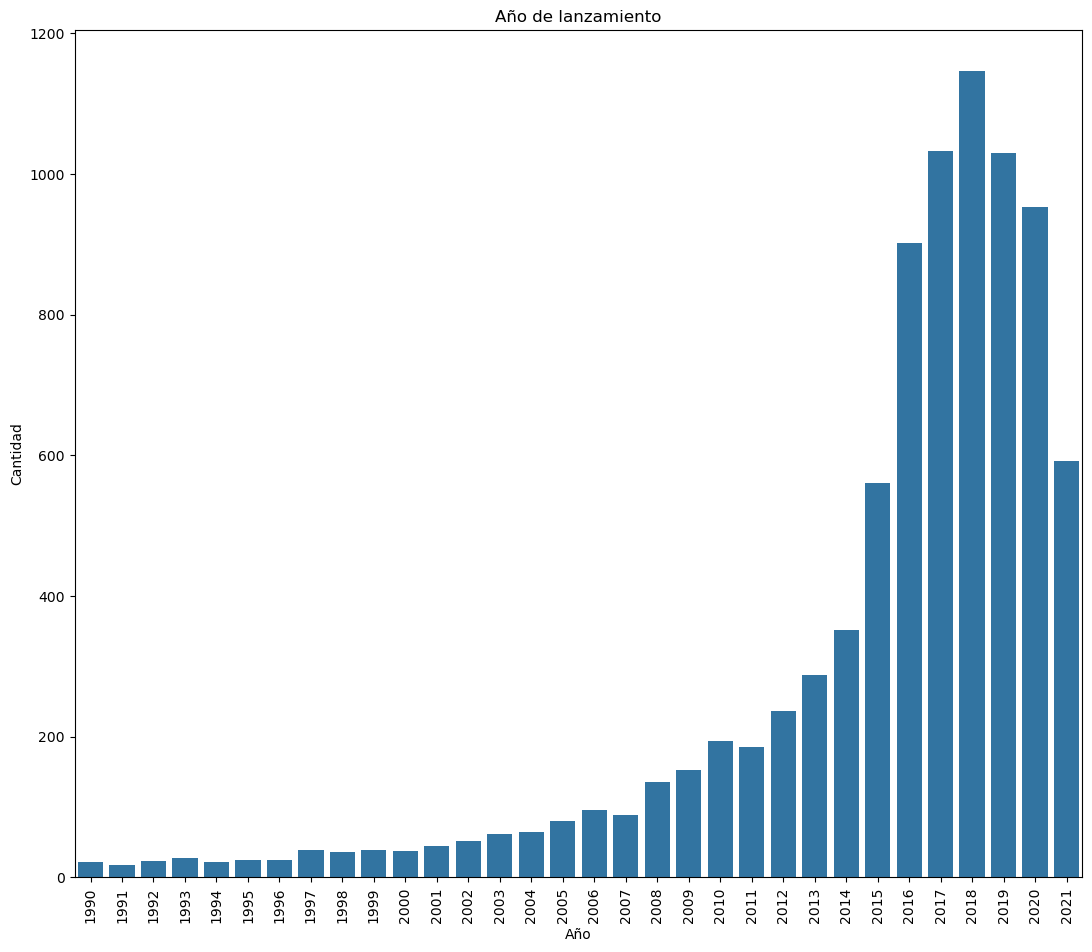

In [8]:
#Grafica 4
plt.figure(figsize=(13,11))

# Filtrar años entre 1990 y 2021
df_filtrado = df[(df["release_year"] >= 1990) & (df["release_year"] <= 2021)]

sns.countplot(data=df_filtrado, x="release_year")

plt.title("Año de lanzamiento")
plt.xlabel("Año")
plt.ylabel("Cantidad")

plt.xticks(rotation=90)

plt.show()

In [ ]:
#Interpretación de patrones (CAPA DE CONOCIMIENTOS Escribe al menos 3 conclusiones derivadas del analisis.

#La columna director contiene una gran cantidad de valores nulos, lo que indica que faltan datos importantes sobre los directores de muchos títulos.
#La mayoria de los contenidos se concentran en ciertos años de lanzamiento, mostrando que la plataforma agrega más títulos recientes que antiguos.
#Algunos ratings aparecen con mucha más frecuencia que otros esto indica contenido está dirigido principalmente a ciertos tipos de audiencia.